# Natural Gas Simulator — Model Validation Dashboard

This notebook validates whether the gas-market simulator is **good enough as a management model**: directional, interpretable, and stable rather than exact.

It checks:
- Storage level error and storage-change error
- Storage direction accuracy
- Price-pressure direction accuracy
- Tight / neutral / loose regime accuracy
- Rolling accuracy through time
- Monte Carlo regime confidence
- A final management-readiness scorecard

> Run this notebook in the same folder as `gas-market-simulator.ipynb`.


## 1. Run or load simulator outputs

Default behavior runs your existing simulator notebook first so this validation dashboard can reuse its objects, especially:

- `best_comparison`
- `comparison`
- `forward_mc_results`
- `forward_mc_summary`
- `forward_signals`
- `grid_df`

If you already exported CSVs instead, set `RUN_SOURCE_NOTEBOOK = False` and load your CSVs in the fallback section.


            production_bcf  demand_bcf  industrial_demand_bcf  storage_bcf  \
2025-12-01        3460.493    3498.325              874.58125         3364   
2026-01-01        3371.529    3789.279              947.31975         2454   
2026-02-01        3098.708    3112.963              778.24075         1876   
2026-03-01        3434.095    2779.452              694.86300         1851   
2026-04-01        3327.661    2389.299              597.32475         2142   

            lng_exports_bcf  henry_hub_price  storage_change_bcf  
2025-12-01          569.267         4.263810              -549.0  
2026-01-01          539.203         7.717895              -910.0  
2026-02-01          493.617         3.621579              -578.0  
2026-03-01          573.479         3.044091               -25.0  
2026-04-01          537.936         2.767619               291.0  

Latest weekly EIA storage release:
{'release_date': Timestamp('2026-06-26 00:00:00'), 'storage_bcf': 2922.0, 'storage_change_bcf

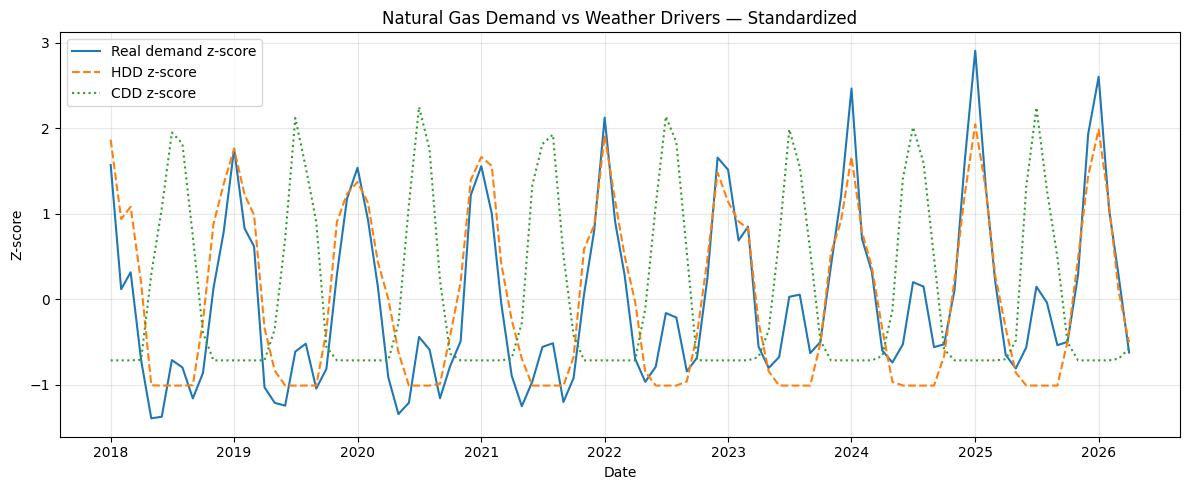

{'storage_price_sensitivity': 1.0, 'storage_change_price_sensitivity': 0.0015, 'price_inertia': 0.5, 'objective': 325.0, 'storage_mae_bcf': 415.6, 'storage_change_mae_bcf': 68.8, 'storage_change_direction_accuracy': 0.98, 'price_pressure_direction_accuracy': 0.515}
Report window: 2023-05-01 to 2026-04-01


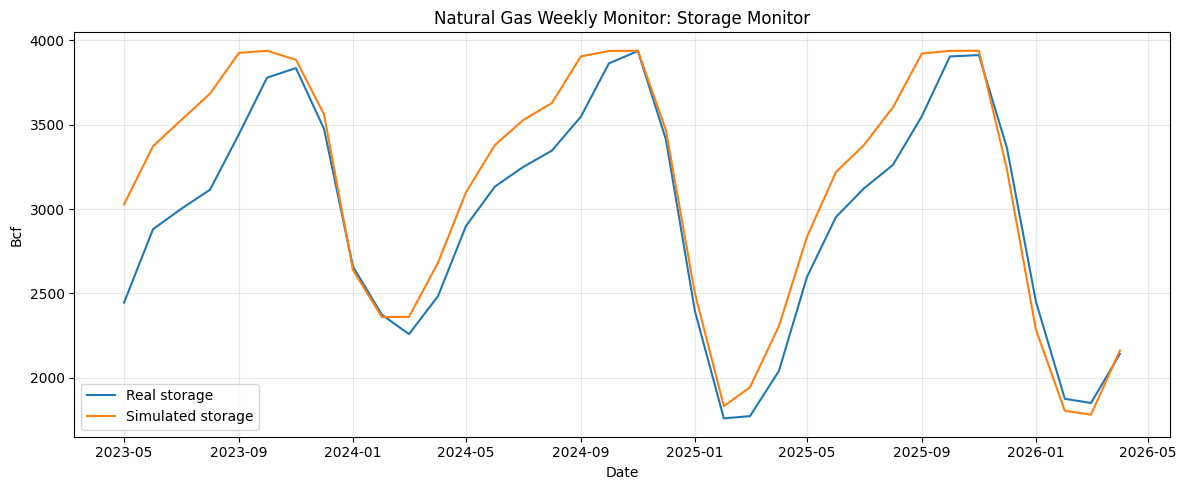

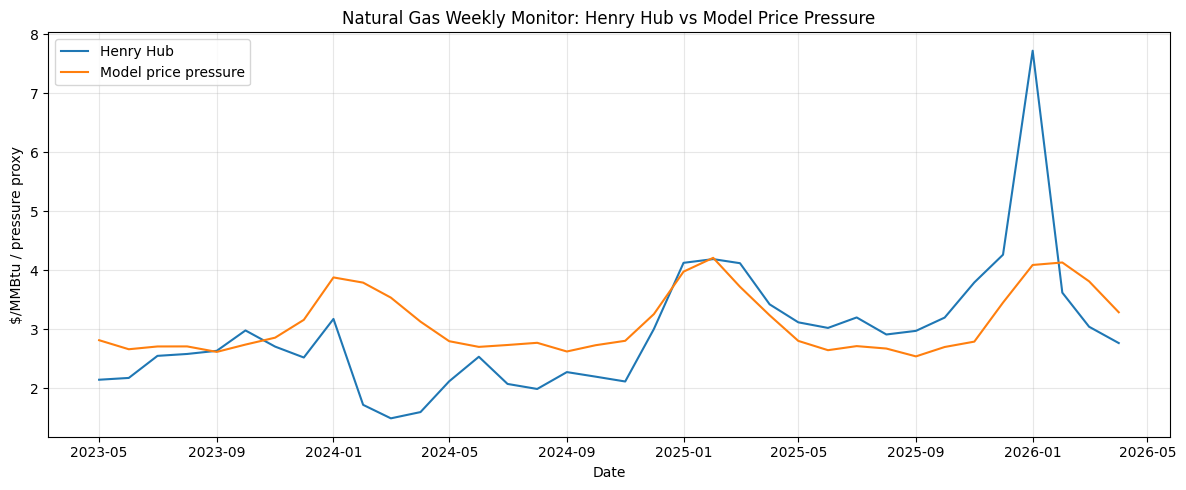

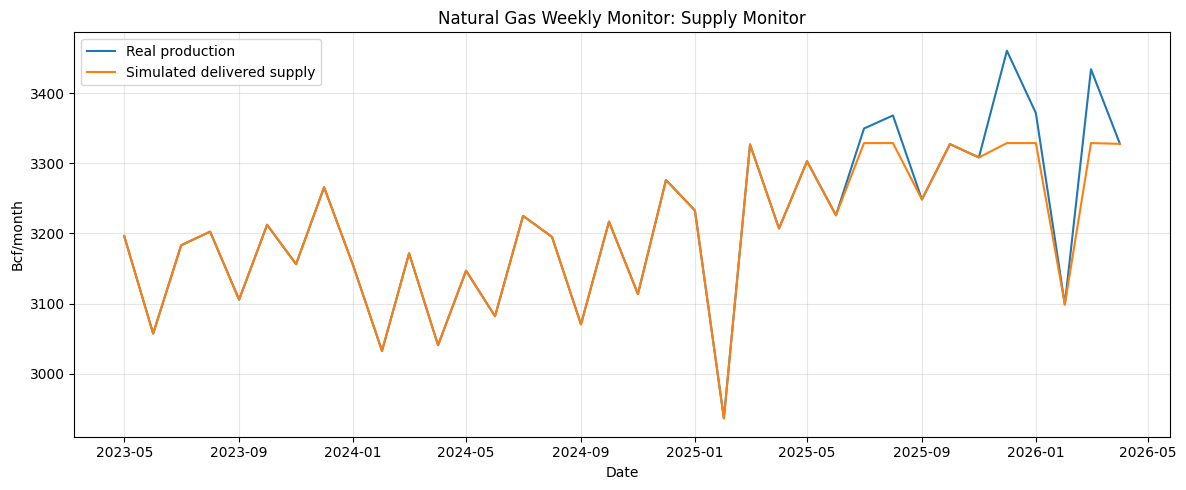

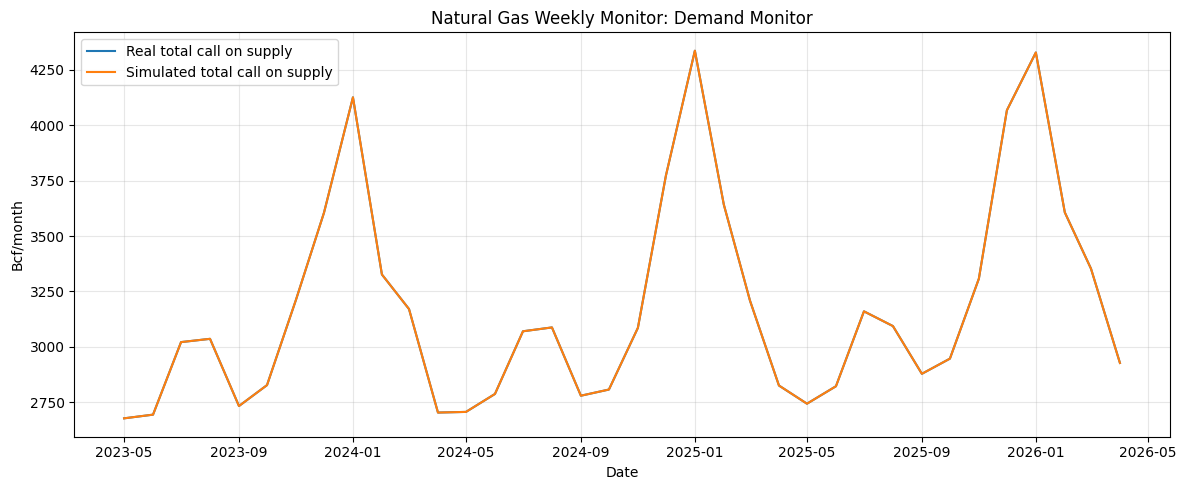

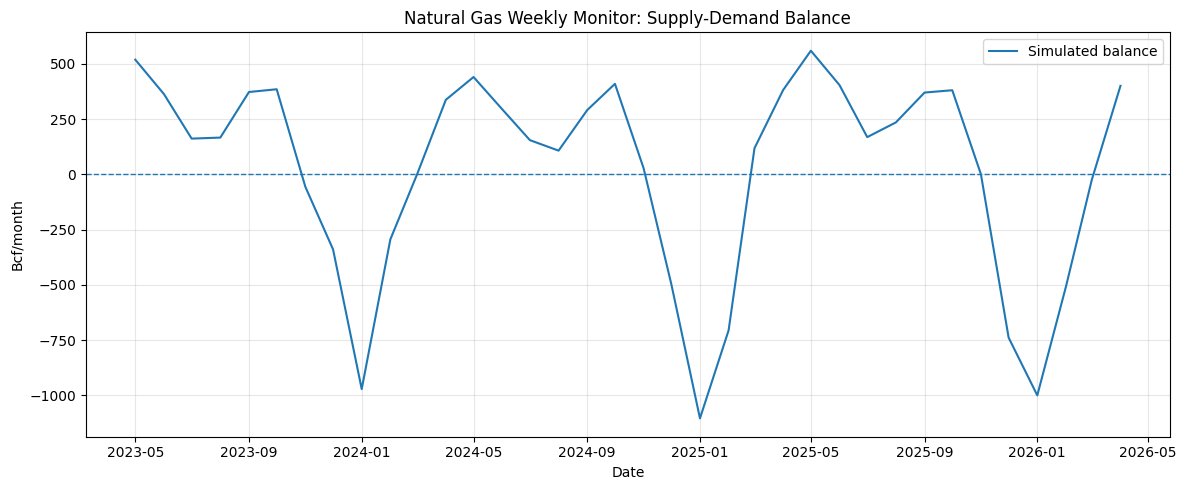

,latest_monthly_date,latest_henry_hub_price,latest_monthly_storage_bcf,latest_monthly_storage_change_bcf
99,2026-04-01,2.767619,2142,291.0


,latest_weekly_storage_release_date,latest_weekly_storage_bcf,latest_weekly_storage_change_bcf
0,2026-06-26,2922.0,87.0


Monte Carlo storage dispersion by month:
scenario         month
Base 3M          1         69.9
                 2         98.8
                 3        127.2
Cold + LNG 3M    1         69.9
                 2         98.8
                 3        127.2
Loose Supply 3M  1         69.9
                 2         98.8
                 3        127.2
Name: storage_bcf, dtype: float64


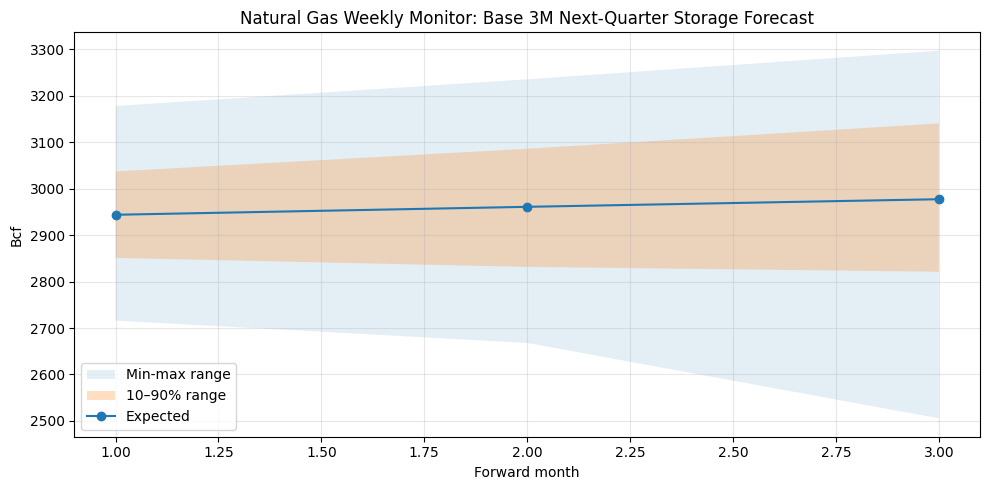

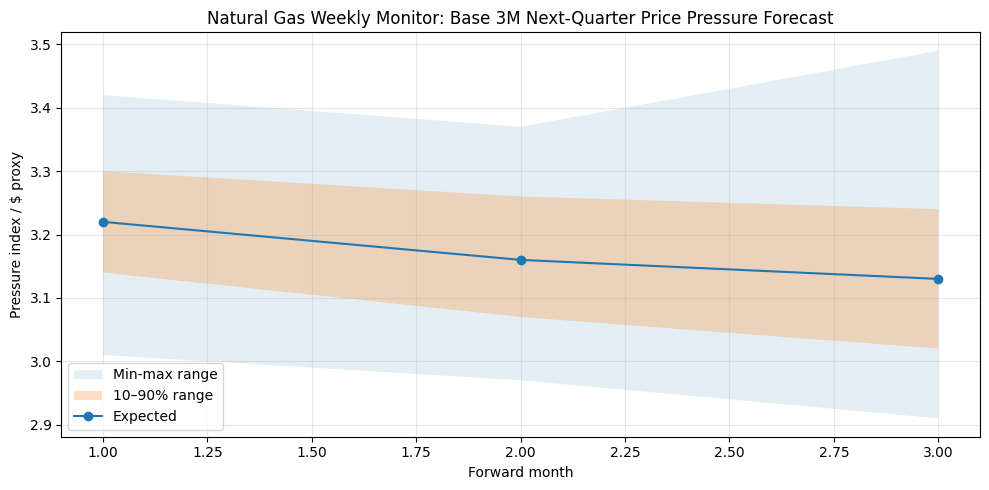

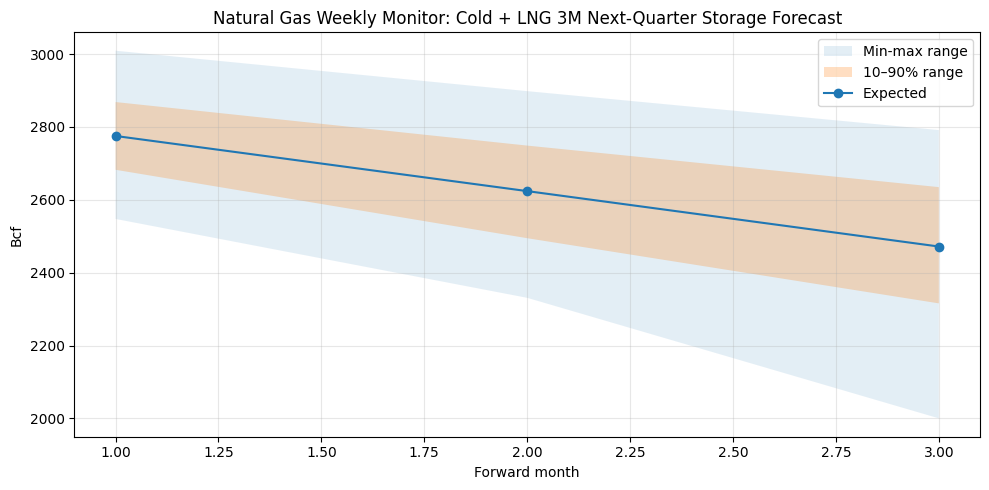

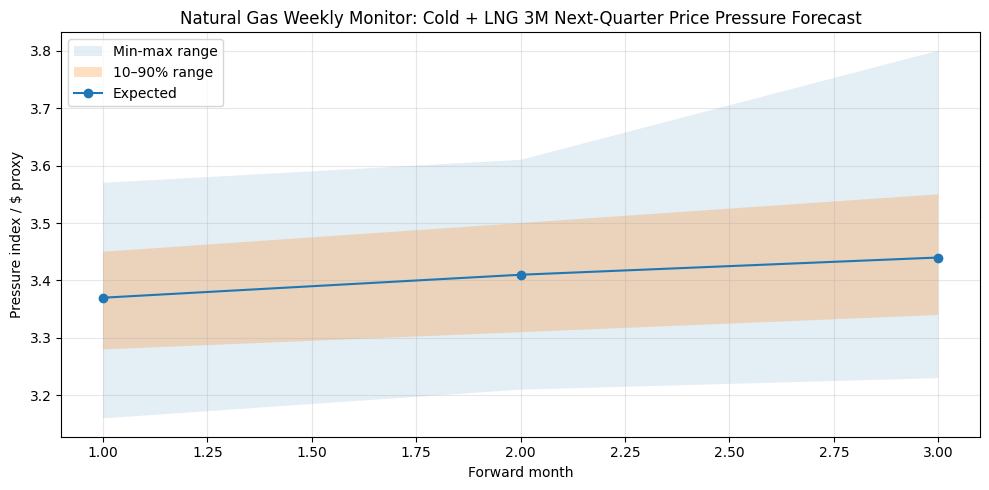

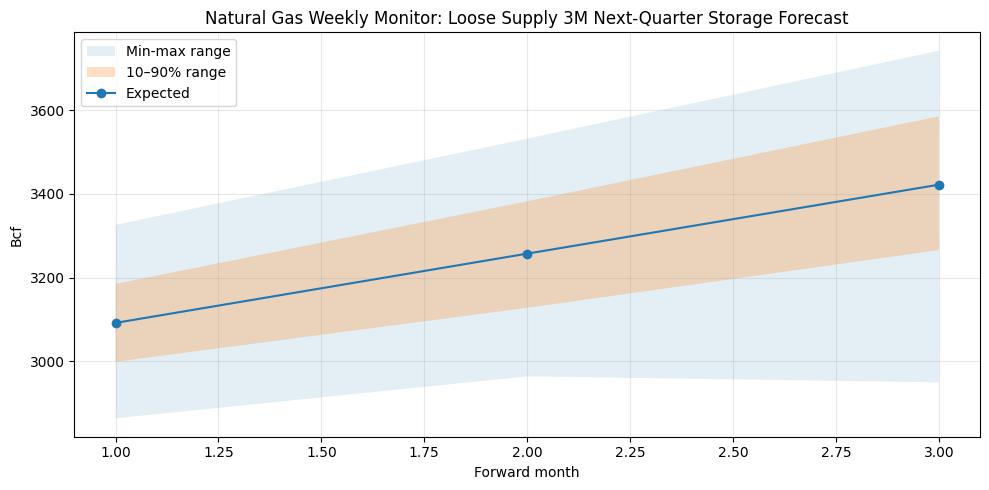

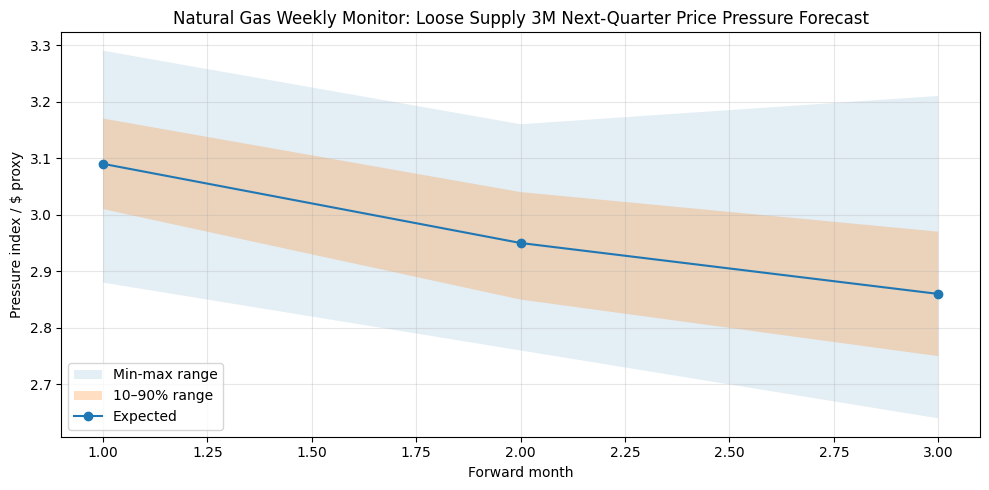

# Natural Gas Weekly Monitor — 2026-07-04

## Current market read
Model pressure is Neutral with a pressure z-score of 0.03. Latest monthly model point is 2,142 Bcf. The latest monthly storage change was 291 Bcf.
Forward forecast anchor: weekly EIA storage release on 2026-06-26 at 2,922 Bcf.

## Next-quarter Monte Carlo scenarios
- Cold + LNG 3M (3M): Neutral pressure, expected conditions. Expected storage path is tightening (-450.2 Bcf over the horizon). Expected ending storage: 2471.8 Bcf (min-max: 2000.0–2791.5 Bcf). Confidence: 0.68.
- Base 3M (3M): Neutral pressure, expected conditions. Expected storage path is balanced (55.3 Bcf over the horizon). Expected ending storage: 2977.2 Bcf (min-max: 2505.5–3297.0 Bcf). Confidence: 0.67.
- Loose Supply 3M (3M): Neutral pressure, expected conditions. Expected storage path is loosening (499.9 Bcf over the horizon). Expected ending storage: 3421.9 Bcf (min-max: 2950.1–3741.7 Bcf). Confidence: 0.73.

## Suggested framing
The model should be 

In [1]:
# Configuration
from pathlib import Path

RUN_SOURCE_NOTEBOOK = True
SOURCE_NOTEBOOK = Path("gas-market-simulator.ipynb")

if RUN_SOURCE_NOTEBOOK:
    if not SOURCE_NOTEBOOK.exists():
        raise FileNotFoundError(f"Could not find {SOURCE_NOTEBOOK}. Put this notebook in the same folder as your simulator notebook.")
    get_ipython().run_line_magic("run", f'"{SOURCE_NOTEBOOK}"')
else:
    print("Skipping source notebook execution. Make sure required CSVs or variables are loaded below.")


In [2]:
# Imports for validation dashboard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 2. Select the backtest dataset

The dashboard prefers `best_comparison` if your grid search was run. Otherwise it falls back to `comparison`.


In [3]:
# Select validation dataframe
if "best_comparison" in globals():
    validation_df = best_comparison.copy()
    VALIDATION_SOURCE = "best_comparison"
elif "comparison" in globals():
    validation_df = comparison.copy()
    VALIDATION_SOURCE = "comparison"
else:
    raise NameError("No comparison dataframe found. Run the simulator notebook or load a comparison CSV.")

if "date" in validation_df.columns:
    validation_df["date"] = pd.to_datetime(validation_df["date"])
else:
    validation_df["date"] = pd.RangeIndex(1, len(validation_df) + 1)

print(f"Using: {VALIDATION_SOURCE}")
print(f"Rows: {len(validation_df):,}")
display(validation_df.tail())


Using: best_comparison
Rows: 100


,date,supply_real,demand_real,industrial_demand_bcf,storage_real,lng_exports_real,price_real,storage_change_real,hdd,cdd,tavg_f,tavg_c,n_weather_days,avg_stations_used,month,regime,price_pressure_sim,supply_sim,delivered_supply_bcf,demand_sim,balance_bcf,storage_start_bcf,storage_end_sim,storage_change_sim,storage_ratio,pipeline_capacity_bcf,lng_exports_sim,scenario,total_demand_real,pressure_z,pressure_signal,pressure_extremeness
95,2025-12-01,3460.493,3498.325,874.58125,3364,569.267,4.263810,-549.0,813.480,0.00,38.758710,3.754839,31,65.000000,96,tight,3.453,3460.5,3328.8,4067.6,-738.8,3938.8,3236.9,-701.9,0.822,3328.75685,290.82506,Best Backtest,4067.592,0.301527,Neutral,Expected
96,2026-01-01,3371.529,3789.279,947.31975,2454,539.203,7.717895,-910.0,993.390,0.00,32.955161,0.530645,31,65.000000,97,tight,4.090,3371.5,3328.8,4328.5,-999.7,3236.9,2287.2,-949.7,0.581,3328.75685,290.82506,Best Backtest,4328.482,1.347958,Bullish,Elevated
97,2026-02-01,3098.708,3112.963,778.24075,1876,493.617,3.621579,-578.0,697.650,0.00,40.083929,4.491071,28,64.964286,98,tight,4.132,3098.7,3098.7,3606.6,-507.9,2287.2,1804.7,-482.5,0.458,3328.75685,290.82506,Best Backtest,3606.580,1.416954,Bullish,Elevated
98,2026-03-01,3434.095,2779.452,694.86300,1851,573.479,3.044091,-25.0,367.290,3.00,53.248710,11.804839,31,65.129032,99,neutral,3.813,3434.1,3328.8,3352.9,-24.2,1804.7,1781.7,-23.0,0.452,3328.75685,290.82506,Best Backtest,3352.931,0.892917,Bullish,Elevated
99,2026-04-01,3327.661,2389.299,597.32475,2142,537.936,2.767619,291.0,166.545,21.96,60.180500,15.655833,30,65.233333,100,loose,3.289,3327.7,3327.7,2927.2,400.4,1781.7,2162.2,380.4,0.549,3328.75685,290.82506,Best Backtest,2927.235,0.032116,Neutral,Expected


## 3. Validation helper functions

In [4]:
# Tunable management-model thresholds
BALANCE_REGIME_THRESHOLD_BCF = 300      # monthly balance threshold for tight/loose classification
STORAGE_CHANGE_THRESHOLD_BCF = 150      # monthly storage-change threshold when balance is unavailable
ROLLING_WINDOW_MONTHS = 12

# Management-readiness gates. Adjust these as your standards mature.
MIN_STORAGE_DIRECTION_ACCURACY = 0.65
MIN_PRICE_DIRECTION_ACCURACY = 0.55
MAX_STORAGE_LEVEL_MAE_BCF = 300
MAX_STORAGE_CHANGE_MAE_BCF = 175
MAX_STORAGE_BIAS_ABS_BCF = 150


def _safe_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def classify_three_way(value, threshold, positive_label="loose", negative_label="tight"):
    if pd.isna(value):
        return np.nan
    if value > threshold:
        return positive_label
    if value < -threshold:
        return negative_label
    return "neutral"


def add_validation_columns(df):
    out = df.copy()

    # Storage errors
    out["storage_error_bcf"] = out["storage_end_sim"] - out["storage_real"]
    out["storage_abs_error_bcf"] = out["storage_error_bcf"].abs()
    out["storage_change_error_bcf"] = out["storage_change_sim"] - out["storage_change_real"]
    out["storage_change_abs_error_bcf"] = out["storage_change_error_bcf"].abs()

    # Directional checks
    out["actual_storage_change_dir"] = np.sign(out["storage_change_real"])
    out["sim_storage_change_dir"] = np.sign(out["storage_change_sim"])
    out["storage_direction_hit"] = out["actual_storage_change_dir"] == out["sim_storage_change_dir"]

    if "price_real" in out.columns and "price_pressure_sim" in out.columns:
        out["real_price_change"] = out["price_real"].diff()
        out["sim_pressure_change"] = out["price_pressure_sim"].diff()
        out["price_direction_hit"] = np.sign(out["real_price_change"]) == np.sign(out["sim_pressure_change"])
    else:
        out["real_price_change"] = np.nan
        out["sim_pressure_change"] = np.nan
        out["price_direction_hit"] = np.nan

    # Actual balance, if possible
    if "supply_real" in out.columns and "total_demand_real" in out.columns:
        out["actual_balance_bcf"] = out["supply_real"] - out["total_demand_real"]
    elif "storage_change_real" in out.columns:
        out["actual_balance_bcf"] = out["storage_change_real"]
    else:
        out["actual_balance_bcf"] = np.nan

    # Simulated balance, if possible
    sim_balance_col = _safe_col(out, ["balance_bcf", "balance_bcf_sim", "sim_balance_bcf"])
    if sim_balance_col:
        out["sim_balance_bcf"] = out[sim_balance_col]
    elif "storage_change_sim" in out.columns:
        out["sim_balance_bcf"] = out["storage_change_sim"]
    else:
        out["sim_balance_bcf"] = np.nan

    out["actual_regime"] = out["actual_balance_bcf"].apply(lambda x: classify_three_way(x, BALANCE_REGIME_THRESHOLD_BCF))
    out["sim_regime"] = out["sim_balance_bcf"].apply(lambda x: classify_three_way(x, BALANCE_REGIME_THRESHOLD_BCF))
    out["regime_hit"] = out["actual_regime"] == out["sim_regime"]

    out["rolling_storage_direction_accuracy"] = out["storage_direction_hit"].rolling(ROLLING_WINDOW_MONTHS).mean()
    out["rolling_price_direction_accuracy"] = out["price_direction_hit"].rolling(ROLLING_WINDOW_MONTHS).mean()
    out["rolling_regime_accuracy"] = out["regime_hit"].rolling(ROLLING_WINDOW_MONTHS).mean()

    return out


def compute_validation_metrics(df):
    valid_storage = df.dropna(subset=["storage_error_bcf", "storage_change_error_bcf"])
    valid_price = df.dropna(subset=["price_direction_hit"])
    valid_regime = df.dropna(subset=["actual_regime", "sim_regime"])

    metrics = {
        "storage_level_mae_bcf": valid_storage["storage_abs_error_bcf"].mean(),
        "storage_level_rmse_bcf": np.sqrt((valid_storage["storage_error_bcf"] ** 2).mean()),
        "storage_level_bias_bcf": valid_storage["storage_error_bcf"].mean(),
        "storage_change_mae_bcf": valid_storage["storage_change_abs_error_bcf"].mean(),
        "storage_change_rmse_bcf": np.sqrt((valid_storage["storage_change_error_bcf"] ** 2).mean()),
        "storage_direction_accuracy": valid_storage["storage_direction_hit"].mean(),
        "price_pressure_direction_accuracy": valid_price["price_direction_hit"].mean() if len(valid_price) else np.nan,
        "regime_accuracy": valid_regime["regime_hit"].mean() if len(valid_regime) else np.nan,
        "n_months": len(df),
    }
    return pd.DataFrame([metrics]).round(3)


validation_df = add_validation_columns(validation_df)
metrics_df = compute_validation_metrics(validation_df)
display(metrics_df)


,storage_level_mae_bcf,storage_level_rmse_bcf,storage_level_bias_bcf,storage_change_mae_bcf,storage_change_rmse_bcf,storage_direction_accuracy,price_pressure_direction_accuracy,regime_accuracy,n_months
0,410.477,523.35,-59.105,68.843,95.183,0.98,0.51,1.0,100


## 4. Management readiness scorecard

This is intentionally simple. The point is not to prove the model is exact. The point is to decide whether it is stable enough for directional management judgment.


In [5]:
def pass_fail(value, rule, threshold):
    if pd.isna(value):
        return "N/A"
    if rule == ">=":
        return "PASS" if value >= threshold else "REVIEW"
    if rule == "<=":
        return "PASS" if value <= threshold else "REVIEW"
    raise ValueError(rule)

m = metrics_df.iloc[0]
scorecard = pd.DataFrame([
    {
        "test": "Storage direction accuracy",
        "value": m["storage_direction_accuracy"],
        "target": f">= {MIN_STORAGE_DIRECTION_ACCURACY}",
        "status": pass_fail(m["storage_direction_accuracy"], ">=", MIN_STORAGE_DIRECTION_ACCURACY),
        "why_it_matters": "Can the model correctly call injection vs withdrawal direction?",
    },
    {
        "test": "Price-pressure direction accuracy",
        "value": m["price_pressure_direction_accuracy"],
        "target": f">= {MIN_PRICE_DIRECTION_ACCURACY}",
        "status": pass_fail(m["price_pressure_direction_accuracy"], ">=", MIN_PRICE_DIRECTION_ACCURACY),
        "why_it_matters": "Does the pressure proxy usually move with Henry Hub direction?",
    },
    {
        "test": "Storage level MAE",
        "value": m["storage_level_mae_bcf"],
        "target": f"<= {MAX_STORAGE_LEVEL_MAE_BCF} Bcf",
        "status": pass_fail(m["storage_level_mae_bcf"], "<=", MAX_STORAGE_LEVEL_MAE_BCF),
        "why_it_matters": "Is the storage path close enough for broad regime analysis?",
    },
    {
        "test": "Storage change MAE",
        "value": m["storage_change_mae_bcf"],
        "target": f"<= {MAX_STORAGE_CHANGE_MAE_BCF} Bcf",
        "status": pass_fail(m["storage_change_mae_bcf"], "<=", MAX_STORAGE_CHANGE_MAE_BCF),
        "why_it_matters": "Are monthly injections/withdrawals approximately sized correctly?",
    },
    {
        "test": "Storage bias",
        "value": abs(m["storage_level_bias_bcf"]),
        "target": f"<= {MAX_STORAGE_BIAS_ABS_BCF} Bcf abs",
        "status": pass_fail(abs(m["storage_level_bias_bcf"]), "<=", MAX_STORAGE_BIAS_ABS_BCF),
        "why_it_matters": "Does the model systematically overstate or understate storage?",
    },
])

pass_count = (scorecard["status"] == "PASS").sum()
review_count = (scorecard["status"] == "REVIEW").sum()

if review_count == 0:
    verdict = "GOOD ENOUGH for management-level directional use."
elif pass_count >= 3:
    verdict = "USABLE, but keep it framed as a directional monitor and review failed gates."
else:
    verdict = "NOT YET reliable enough for management use without recalibration."

display(scorecard)
display(Markdown(f"### Verdict: {verdict}"))


,test,value,target,status,why_it_matters
0,Storage direction accuracy,0.980,>= 0.65,PASS,Can the model correctly call injection vs with...
1,Price-pressure direction accuracy,0.510,>= 0.55,REVIEW,Does the pressure proxy usually move with Henr...
2,Storage level MAE,410.477,<= 300 Bcf,REVIEW,Is the storage path close enough for broad reg...
3,Storage change MAE,68.843,<= 175 Bcf,PASS,Are monthly injections/withdrawals approximate...
4,Storage bias,59.105,<= 150 Bcf abs,PASS,Does the model systematically overstate or und...


### Verdict: USABLE, but keep it framed as a directional monitor and review failed gates.

## 5. Backtest dashboard plots

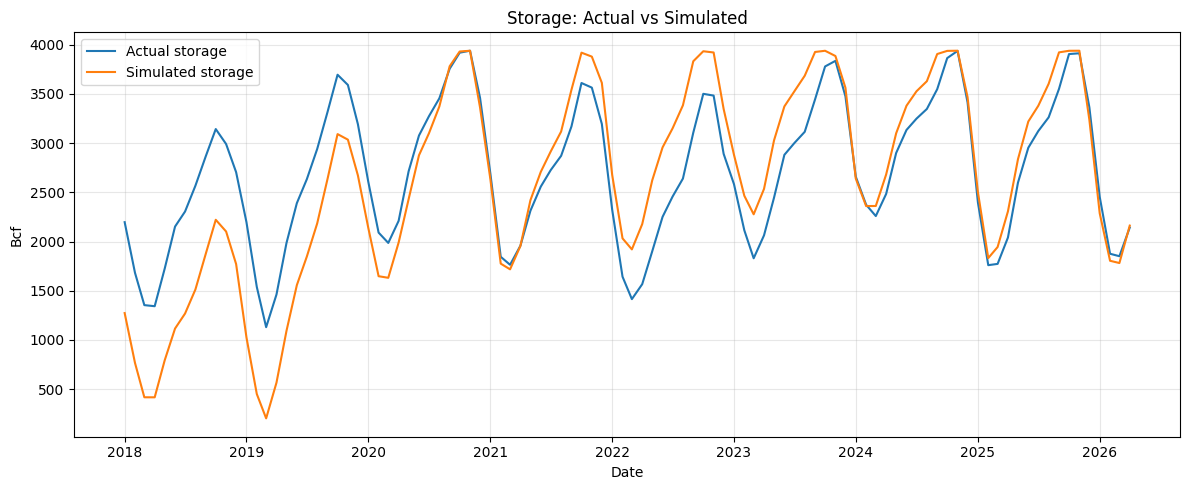

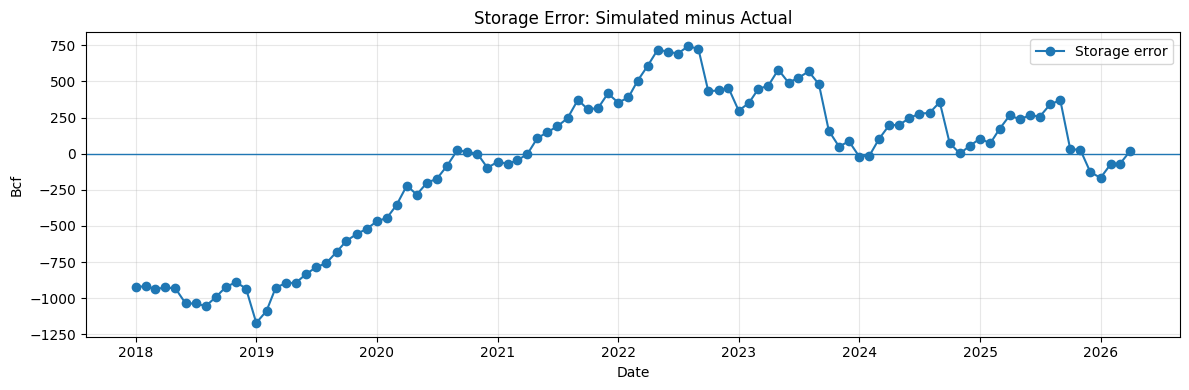

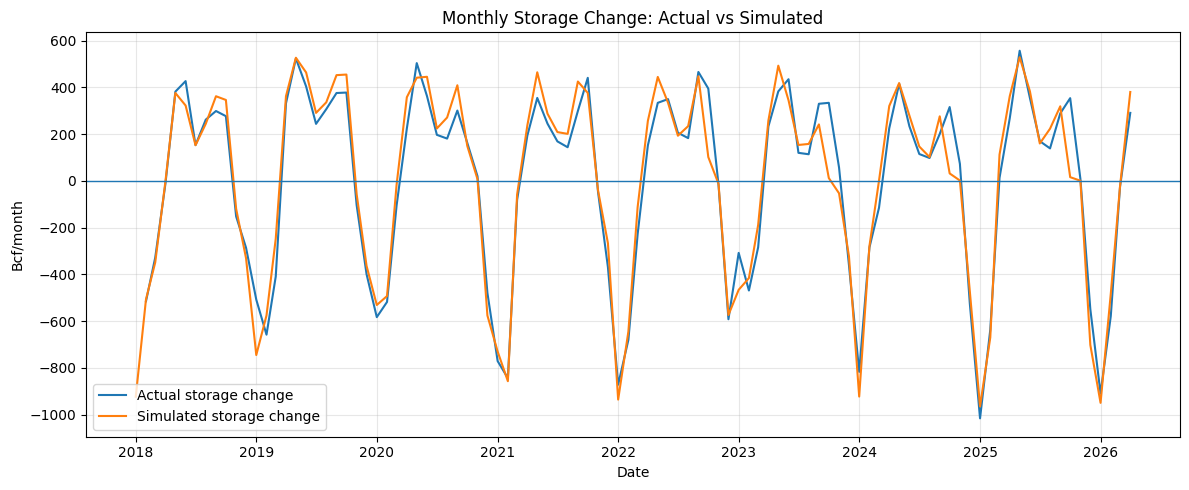

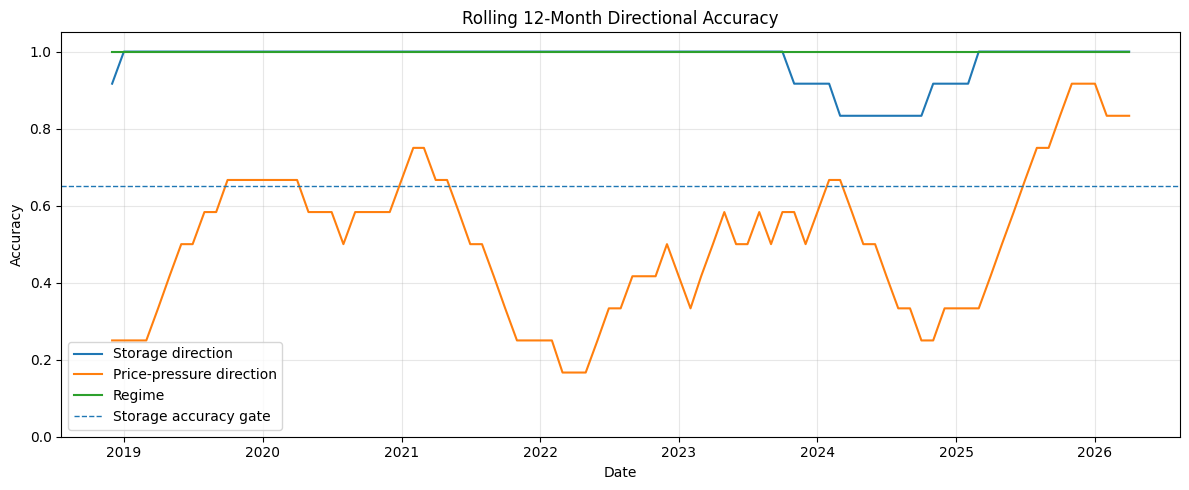

In [6]:
def plot_storage_actual_vs_sim(df):
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["storage_real"], label="Actual storage")
    plt.plot(df["date"], df["storage_end_sim"], label="Simulated storage")
    plt.title("Storage: Actual vs Simulated")
    plt.xlabel("Date")
    plt.ylabel("Bcf")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_storage_error(df):
    plt.figure(figsize=(12, 4))
    plt.axhline(0, linewidth=1)
    plt.plot(df["date"], df["storage_error_bcf"], marker="o", label="Storage error")
    plt.title("Storage Error: Simulated minus Actual")
    plt.xlabel("Date")
    plt.ylabel("Bcf")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_storage_change_actual_vs_sim(df):
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["storage_change_real"], label="Actual storage change")
    plt.plot(df["date"], df["storage_change_sim"], label="Simulated storage change")
    plt.axhline(0, linewidth=1)
    plt.title("Monthly Storage Change: Actual vs Simulated")
    plt.xlabel("Date")
    plt.ylabel("Bcf/month")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_rolling_accuracy(df):
    plt.figure(figsize=(12, 5))
    plt.plot(df["date"], df["rolling_storage_direction_accuracy"], label="Storage direction")
    plt.plot(df["date"], df["rolling_price_direction_accuracy"], label="Price-pressure direction")
    plt.plot(df["date"], df["rolling_regime_accuracy"], label="Regime")
    plt.axhline(MIN_STORAGE_DIRECTION_ACCURACY, linestyle="--", linewidth=1, label="Storage accuracy gate")
    plt.title(f"Rolling {ROLLING_WINDOW_MONTHS}-Month Directional Accuracy")
    plt.xlabel("Date")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_storage_actual_vs_sim(validation_df)
plot_storage_error(validation_df)
plot_storage_change_actual_vs_sim(validation_df)
plot_rolling_accuracy(validation_df)


## 6. Price-pressure validation

This does **not** test whether the model exactly predicts Henry Hub. It tests whether the model pressure proxy moves in the same broad direction as price.


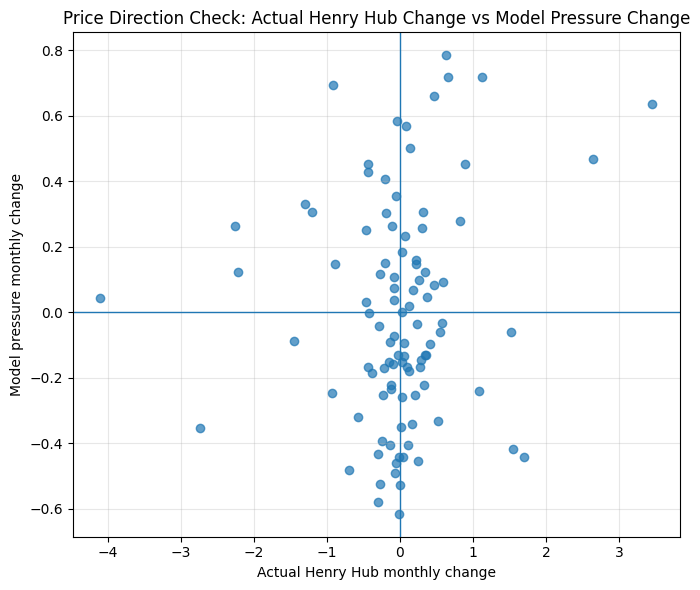

sim_pressure_dir,down,up,All
actual_price_dir,,,
down,27,21,48
up,27,24,51
All,54,45,99


In [7]:
def plot_price_pressure_direction(df):
    needed = ["real_price_change", "sim_pressure_change"]
    if not all(c in df.columns for c in needed):
        print("Price columns unavailable.")
        return

    g = df.dropna(subset=needed).copy()
    plt.figure(figsize=(7, 6))
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.scatter(g["real_price_change"], g["sim_pressure_change"], alpha=0.7)
    plt.title("Price Direction Check: Actual Henry Hub Change vs Model Pressure Change")
    plt.xlabel("Actual Henry Hub monthly change")
    plt.ylabel("Model pressure monthly change")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def price_direction_table(df):
    g = df.dropna(subset=["real_price_change", "sim_pressure_change"]).copy()
    g["actual_price_dir"] = np.where(g["real_price_change"] > 0, "up", np.where(g["real_price_change"] < 0, "down", "flat"))
    g["sim_pressure_dir"] = np.where(g["sim_pressure_change"] > 0, "up", np.where(g["sim_pressure_change"] < 0, "down", "flat"))
    return pd.crosstab(g["actual_price_dir"], g["sim_pressure_dir"], margins=True)

plot_price_pressure_direction(validation_df)
display(price_direction_table(validation_df))


## 7. Regime validation: tight / neutral / loose

sim_regime,loose,neutral,tight
actual_regime,,,
loose,36,0,0
neutral,0,39,0
tight,0,0,25


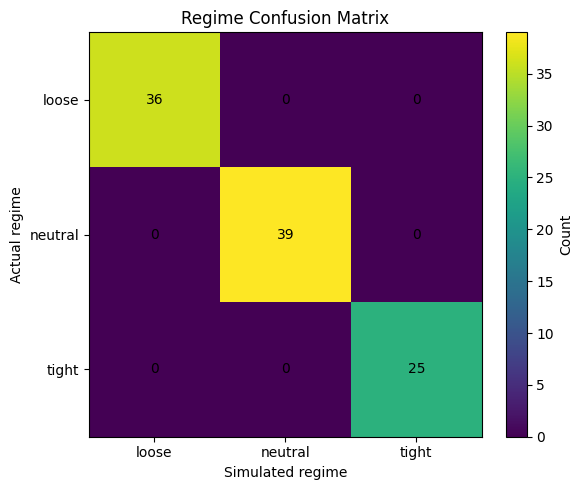

,date,actual_balance_bcf,sim_balance_bcf,actual_regime,sim_regime,regime_hit,storage_change_real,storage_change_sim,price_real,price_pressure_sim
76,2024-05-01,440.445,440.4,loose,loose,True,416.0,418.4,2.120455,2.799
77,2024-06-01,294.574,294.6,neutral,neutral,True,234.0,279.8,2.535789,2.703
78,2024-07-01,154.800,154.8,neutral,neutral,True,115.0,147.1,2.075455,2.735
79,2024-08-01,107.444,107.4,neutral,neutral,True,98.0,102.1,1.990455,2.772
80,2024-09-01,290.842,290.8,neutral,neutral,True,201.0,276.3,2.276000,2.625
81,2024-10-01,409.574,409.6,loose,loose,True,316.0,31.9,2.199091,2.731
82,2024-11-01,27.995,28.0,neutral,neutral,True,73.0,1.6,2.117000,2.806
83,2024-12-01,-496.543,-496.5,tight,tight,True,-524.0,-471.7,3.005714,3.258
84,2025-01-01,-1103.683,-1103.7,tight,tight,True,-1016.0,-965.2,4.126190,3.977
85,2025-02-01,-705.367,-705.4,tight,tight,True,-637.0,-670.1,4.188947,4.211


In [8]:
def plot_confusion_matrix(cm, title):
    labels = list(cm.index)
    values = cm.to_numpy()

    plt.figure(figsize=(6, 5))
    plt.imshow(values, aspect="auto")
    plt.title(title)
    plt.xlabel("Simulated regime")
    plt.ylabel("Actual regime")
    plt.xticks(range(len(cm.columns)), cm.columns)
    plt.yticks(range(len(cm.index)), cm.index)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            plt.text(j, i, int(values[i, j]), ha="center", va="center")

    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()

regime_cm = pd.crosstab(validation_df["actual_regime"], validation_df["sim_regime"])
display(regime_cm)
plot_confusion_matrix(regime_cm, "Regime Confusion Matrix")

regime_review = validation_df[[
    "date", "actual_balance_bcf", "sim_balance_bcf", "actual_regime", "sim_regime", "regime_hit",
    "storage_change_real", "storage_change_sim", "price_real", "price_pressure_sim"
]].tail(24)

display(regime_review)


## 8. Error distribution and worst misses

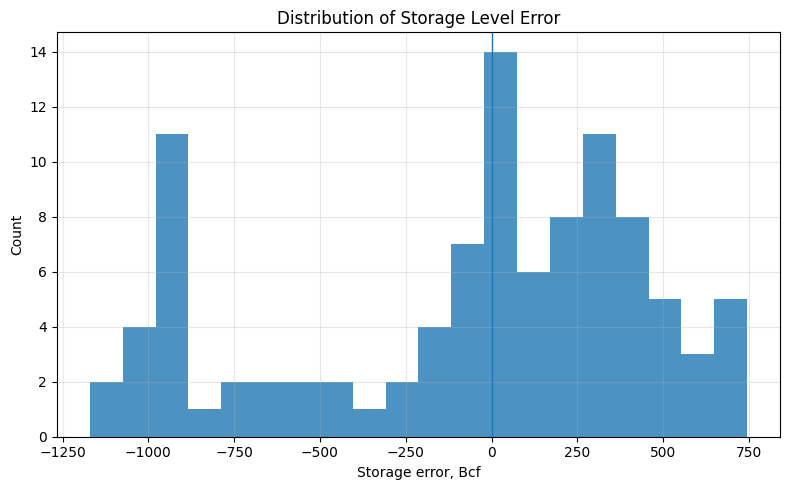

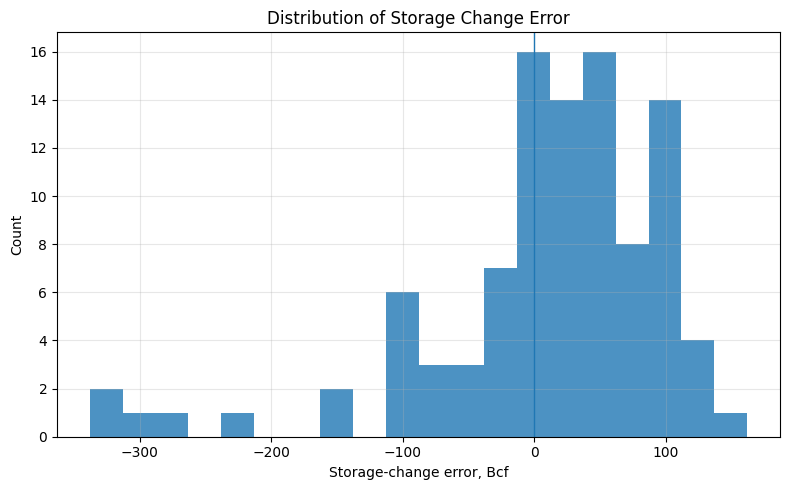

,date,storage_change_real,storage_change_sim,storage_change_error_bcf,actual_regime,sim_regime,price_real,price_pressure_sim
93,2025-10-01,354.0,16.0,-338.0,loose,loose,3.199091,2.701
69,2023-10-01,334.0,12.1,-321.9,loose,loose,2.981429,2.742
57,2022-10-01,395.0,101.9,-293.1,loose,loose,5.660500,2.610
81,2024-10-01,316.0,31.9,-284.1,loose,loose,2.199091,2.731
12,2019-01-01,-508.0,-745.2,-237.2,tight,tight,3.123182,4.298
14,2019-03-01,-409.0,-247.1,161.9,neutral,neutral,2.948571,4.849
60,2023-01-01,-308.0,-466.0,-158.0,tight,tight,3.273000,3.589
95,2025-12-01,-549.0,-701.9,-152.9,tight,tight,4.263810,3.453
27,2020-04-01,224.0,357.9,133.9,loose,loose,1.739048,3.309
44,2021-09-01,299.0,425.2,126.2,loose,loose,5.161429,2.587


In [9]:
def plot_error_histograms(df):
    plt.figure(figsize=(8, 5))
    plt.hist(df["storage_error_bcf"].dropna(), bins=20, alpha=0.8)
    plt.axvline(0, linewidth=1)
    plt.title("Distribution of Storage Level Error")
    plt.xlabel("Storage error, Bcf")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(df["storage_change_error_bcf"].dropna(), bins=20, alpha=0.8)
    plt.axvline(0, linewidth=1)
    plt.title("Distribution of Storage Change Error")
    plt.xlabel("Storage-change error, Bcf")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_error_histograms(validation_df)

worst_misses = (
    validation_df
    .sort_values("storage_change_abs_error_bcf", ascending=False)
    [["date", "storage_change_real", "storage_change_sim", "storage_change_error_bcf", "actual_regime", "sim_regime", "price_real", "price_pressure_sim"]]
    .head(12)
)

display(worst_misses)


## 9. Monte Carlo confidence dashboard

This section validates the **forward scenario confidence**. A useful management model should not only say “tight” or “loose”; it should say how often the simulated paths agree.


In [10]:
def build_mc_regime_confidence(mc_df):
    required = {"scenario", "simulation", "month", "storage_change_bcf"}
    missing = required - set(mc_df.columns)
    if missing:
        raise ValueError(f"forward_mc_results is missing columns: {missing}")

    path_summary = (
        mc_df
        .groupby(["scenario", "simulation"], as_index=False)
        .agg(
            total_storage_change_bcf=("storage_change_bcf", "sum"),
            ending_storage_bcf=("storage_bcf", "last"),
            avg_balance_bcf=("balance_bcf", "mean") if "balance_bcf" in mc_df.columns else ("storage_change_bcf", "mean"),
            avg_price_pressure=("price", "mean") if "price" in mc_df.columns else ("storage_bcf", "mean"),
        )
    )

    path_summary["path_regime"] = path_summary["total_storage_change_bcf"].apply(
        lambda x: classify_three_way(x, STORAGE_CHANGE_THRESHOLD_BCF)
    )

    shares = (
        path_summary
        .groupby("scenario")["path_regime"]
        .value_counts(normalize=True)
        .rename("share")
        .reset_index()
    )

    confidence = (
        shares
        .sort_values(["scenario", "share"], ascending=[True, False])
        .groupby("scenario", as_index=False)
        .first()
        .rename(columns={"path_regime": "dominant_regime", "share": "confidence"})
    )

    ending_stats = (
        path_summary
        .groupby("scenario", as_index=False)
        .agg(
            expected_total_storage_change_bcf=("total_storage_change_bcf", "mean"),
            p10_total_storage_change_bcf=("total_storage_change_bcf", lambda x: x.quantile(0.10)),
            p90_total_storage_change_bcf=("total_storage_change_bcf", lambda x: x.quantile(0.90)),
            expected_ending_storage_bcf=("ending_storage_bcf", "mean"),
            p10_ending_storage_bcf=("ending_storage_bcf", lambda x: x.quantile(0.10)),
            p90_ending_storage_bcf=("ending_storage_bcf", lambda x: x.quantile(0.90)),
        )
    )

    out = confidence.merge(ending_stats, on="scenario")
    numeric = out.select_dtypes(include=[np.number]).columns
    out[numeric] = out[numeric].round(2)
    return path_summary, shares, out

if "forward_mc_results" in globals():
    mc_path_summary, mc_regime_shares, mc_confidence = build_mc_regime_confidence(forward_mc_results.copy())
    display(mc_confidence)
else:
    print("No forward_mc_results found. Run the simulator notebook first.")


,scenario,dominant_regime,confidence,expected_total_storage_change_bcf,p10_total_storage_change_bcf,p90_total_storage_change_bcf,expected_ending_storage_bcf,p10_ending_storage_bcf,p90_ending_storage_bcf
0,Base 3M,neutral,0.72,55.25,-100.81,218.24,2977.25,2821.19,3140.33
1,Cold + LNG 3M,tight,0.99,-450.23,-606.31,-287.26,2471.77,2315.69,2634.83
2,Loose Supply 3M,loose,0.99,499.91,343.89,662.94,3421.91,3265.89,3584.94


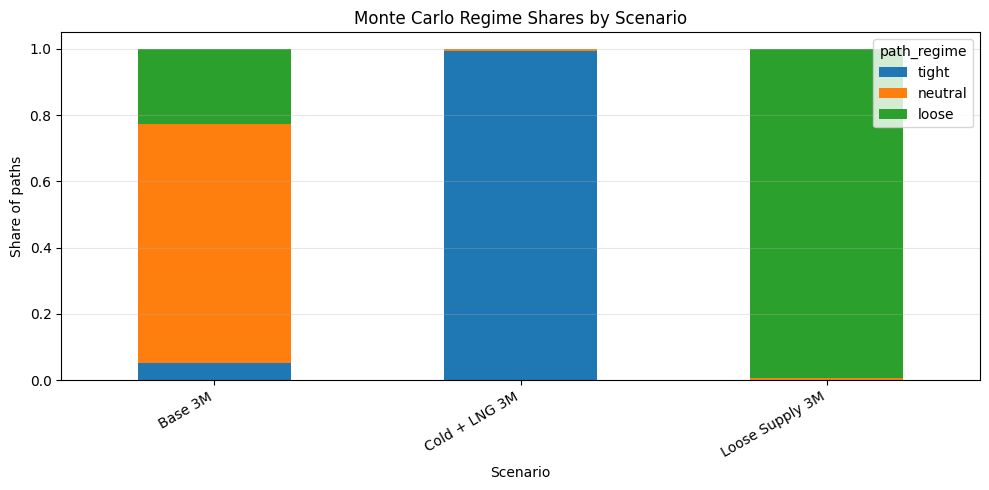

/var/folders/nf/0f78fmr95hz6c9cwnjjzzdlr0000gp/T/ipykernel_3913/638516352.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=scenarios, showmeans=True)


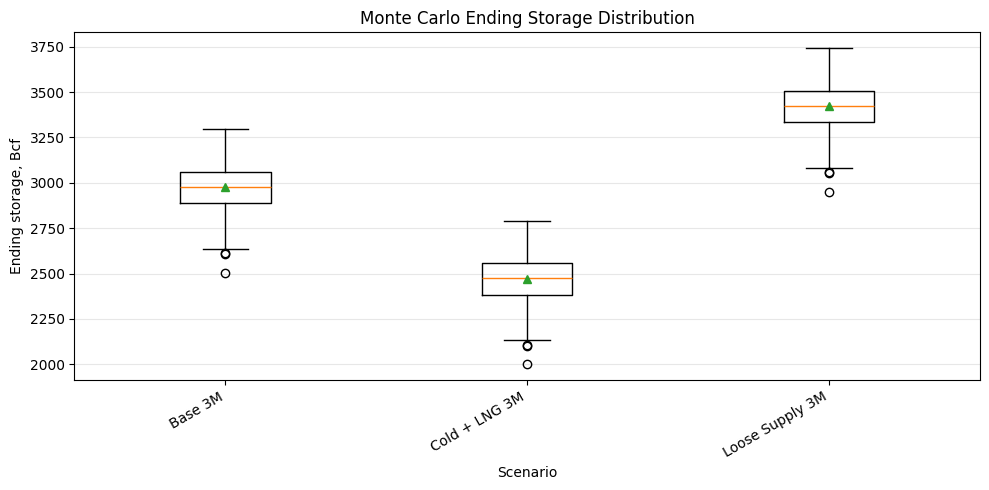

In [11]:
def plot_mc_regime_shares(shares):
    pivot = shares.pivot(index="scenario", columns="path_regime", values="share").fillna(0)
    for col in ["tight", "neutral", "loose"]:
        if col not in pivot.columns:
            pivot[col] = 0.0
    pivot = pivot[["tight", "neutral", "loose"]]

    ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 5))
    ax.set_title("Monte Carlo Regime Shares by Scenario")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Share of paths")
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def plot_mc_ending_storage(path_summary):
    scenarios = path_summary["scenario"].unique()
    data = [path_summary.loc[path_summary["scenario"] == s, "ending_storage_bcf"].dropna() for s in scenarios]

    plt.figure(figsize=(10, 5))
    plt.boxplot(data, labels=scenarios, showmeans=True)
    plt.title("Monte Carlo Ending Storage Distribution")
    plt.xlabel("Scenario")
    plt.ylabel("Ending storage, Bcf")
    plt.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

if "mc_regime_shares" in globals():
    plot_mc_regime_shares(mc_regime_shares)
    plot_mc_ending_storage(mc_path_summary)


## 10. Calibration grid review

Use this to see whether the selected parameters are stable or whether the “best” setting is fragile.


,storage_price_sensitivity,storage_change_price_sensitivity,price_inertia,objective,storage_mae_bcf,storage_change_mae_bcf,storage_change_direction_accuracy,price_pressure_direction_accuracy
6,1.0,0.0015,0.50,325.0,415.6,68.8,0.98,0.515
9,1.0,0.0020,0.50,326.0,415.6,68.8,0.98,0.505
12,1.5,0.0005,0.50,326.0,415.6,68.8,0.98,0.505
21,1.5,0.0020,0.50,326.0,415.6,68.8,0.98,0.505
51,3.0,0.0010,0.50,326.0,415.6,68.8,0.98,0.505
43,2.5,0.0015,0.65,326.0,415.6,68.8,0.98,0.505
8,1.0,0.0015,0.80,327.0,415.6,68.8,0.98,0.495
11,1.0,0.0020,0.80,327.0,415.6,68.8,0.98,0.495
18,1.5,0.0015,0.50,327.0,415.6,68.8,0.98,0.495
23,1.5,0.0020,0.80,327.0,415.6,68.8,0.98,0.495


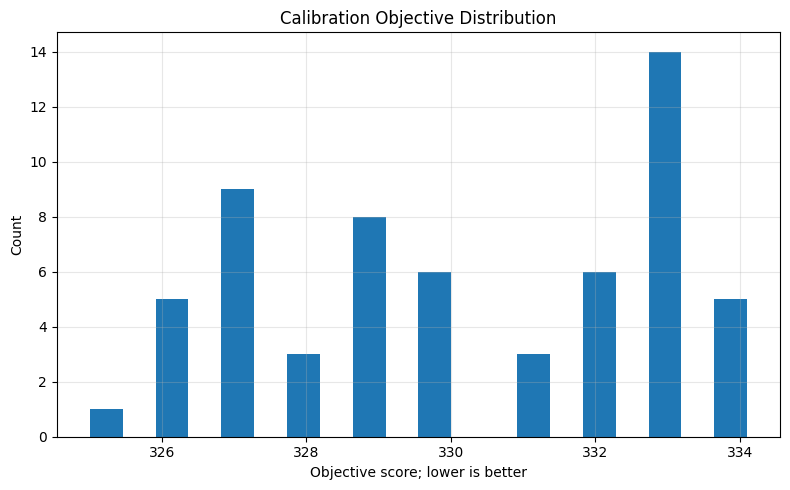

In [12]:
if "grid_df" in globals():
    display(grid_df.head(15))

    plt.figure(figsize=(8, 5))
    plt.hist(grid_df["objective"].dropna(), bins=20)
    plt.title("Calibration Objective Distribution")
    plt.xlabel("Objective score; lower is better")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No grid_df found. Skip this section if you did not run parameter grid search.")


## 11. Final validation memo

This cell generates a plain-English memo you can use inside Energy Atlas or your own notes.


In [13]:
def build_validation_memo(metrics_df, scorecard, mc_confidence=None):
    m = metrics_df.iloc[0]
    failed = scorecard.loc[scorecard["status"] == "REVIEW", "test"].tolist()

    lines = []
    lines.append("## Model Validation Memo")
    lines.append("")
    lines.append(f"Backtest period contains **{int(m['n_months'])} monthly observations**.")
    lines.append(f"Storage level MAE is **{m['storage_level_mae_bcf']:.1f} Bcf** with bias of **{m['storage_level_bias_bcf']:.1f} Bcf**.")
    lines.append(f"Storage-change MAE is **{m['storage_change_mae_bcf']:.1f} Bcf**.")
    lines.append(f"Storage direction accuracy is **{m['storage_direction_accuracy']:.1%}**.")
    if not pd.isna(m['price_pressure_direction_accuracy']):
        lines.append(f"Price-pressure direction accuracy is **{m['price_pressure_direction_accuracy']:.1%}**.")
    if not pd.isna(m['regime_accuracy']):
        lines.append(f"Tight / neutral / loose regime accuracy is **{m['regime_accuracy']:.1%}**.")
    lines.append("")

    if not failed:
        lines.append("**Conclusion:** The simulator is good enough for management-level directional use, assuming it is described as a pressure/regime monitor rather than an exact price forecast.")
    else:
        lines.append("**Conclusion:** The simulator is useful directionally, but the following gates need review before relying on it for stronger decisions:")
        for item in failed:
            lines.append(f"- {item}")

    if mc_confidence is not None:
        lines.append("")
        lines.append("### Forward Monte Carlo confidence")
        for row in mc_confidence.to_dict("records"):
            lines.append(
                f"- **{row['scenario']}**: dominant regime is **{row['dominant_regime']}** "
                f"with **{row['confidence']:.0%}** path agreement. Expected ending storage is "
                f"**{row['expected_ending_storage_bcf']:,.0f} Bcf**."
            )

    return "\n".join(lines)


memo = build_validation_memo(metrics_df, scorecard, globals().get("mc_confidence"))
display(Markdown(memo))


## Model Validation Memo

Backtest period contains **100 monthly observations**.
Storage level MAE is **410.5 Bcf** with bias of **-59.1 Bcf**.
Storage-change MAE is **68.8 Bcf**.
Storage direction accuracy is **98.0%**.
Price-pressure direction accuracy is **51.0%**.
Tight / neutral / loose regime accuracy is **100.0%**.

**Conclusion:** The simulator is useful directionally, but the following gates need review before relying on it for stronger decisions:
- Price-pressure direction accuracy
- Storage level MAE

### Forward Monte Carlo confidence
- **Base 3M**: dominant regime is **neutral** with **72%** path agreement. Expected ending storage is **2,977 Bcf**.
- **Cold + LNG 3M**: dominant regime is **tight** with **99%** path agreement. Expected ending storage is **2,472 Bcf**.
- **Loose Supply 3M**: dominant regime is **loose** with **99%** path agreement. Expected ending storage is **3,422 Bcf**.

## 12. Optional export

In [14]:
EXPORT_VALIDATION_OUTPUTS = False

if EXPORT_VALIDATION_OUTPUTS:
    validation_df.to_csv("gas_model_validation_backtest.csv", index=False)
    metrics_df.to_csv("gas_model_validation_metrics.csv", index=False)
    scorecard.to_csv("gas_model_validation_scorecard.csv", index=False)
    if "mc_confidence" in globals():
        mc_confidence.to_csv("gas_model_mc_confidence.csv", index=False)
    with open("gas_model_validation_memo.md", "w") as f:
        f.write(memo)
    print("Exported validation outputs.")
